In [1]:
from fns import kl_divergence,kl_loss,entropy
from dataset import CIFAR10H_Dataset
from config import classes
from model import SimpleCNN
from torch.utils.data import random_split, DataLoader
import torch
import numpy as np
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt 

In [2]:
cifar10h = np.load("cifar10h-probs.npy")

In [3]:


transform = transforms.Compose([
    transforms.ToTensor()
])

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [4]:

dataset_size = len(testset)

train_size = 6000
val_size = 2000
test_size = 2000

train_data, val_data, test_data = random_split(
    list(range(dataset_size)),
    [train_size, val_size, test_size]
)

In [5]:
train_dataset = CIFAR10H_Dataset(train_data, testset, cifar10h)
val_dataset   = CIFAR10H_Dataset(val_data, testset, cifar10h)
test_dataset  = CIFAR10H_Dataset(test_data, testset, cifar10h)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [6]:
model = SimpleCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses=[]
val_losses=[]

for epoch in range(10):
    model.train()
    train_loss=0
    
    for images, targets in train_loader:
        # logits = model(images)
        # outputs = torch.softmax(logits, dim=1)

        # loss = kl_divergence(targets, outputs)
        outputs = model(images)

        loss = kl_loss(targets, outputs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)
    
    print(f"Epoch {epoch}, Loss: {loss.item()}")


    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, targets in val_loader:
            output = model(images)
            loss = kl_loss(targets, output)
            val_loss += loss.item() * images.size(0)

    val_loss /= len(val_dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
    print("----------------------------------")


Epoch 0, Loss: 1.650077223777771
Epoch 0, Train Loss: 1.8175, Val Loss: 1.6161
----------------------------------
Epoch 1, Loss: 1.3424471616744995
Epoch 1, Train Loss: 1.4822, Val Loss: 1.4656
----------------------------------
Epoch 2, Loss: 1.2848321199417114
Epoch 2, Train Loss: 1.3400, Val Loss: 1.3346
----------------------------------
Epoch 3, Loss: 1.049181342124939
Epoch 3, Train Loss: 1.2424, Val Loss: 1.2747
----------------------------------
Epoch 4, Loss: 1.2198611497879028
Epoch 4, Train Loss: 1.1672, Val Loss: 1.2229
----------------------------------
Epoch 5, Loss: 1.2690434455871582
Epoch 5, Train Loss: 1.0729, Val Loss: 1.1786
----------------------------------
Epoch 6, Loss: 0.8756080269813538
Epoch 6, Train Loss: 1.0000, Val Loss: 1.1703
----------------------------------
Epoch 7, Loss: 0.9811988472938538
Epoch 7, Train Loss: 0.9266, Val Loss: 1.1577
----------------------------------
Epoch 8, Loss: 0.9210354685783386
Epoch 8, Train Loss: 0.8734, Val Loss: 1.1285
--

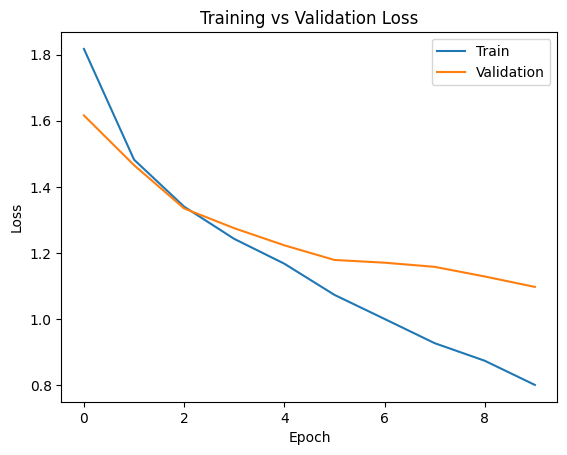

In [7]:
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [8]:
test_loss = 0

model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        logits = model(images)
        loss = kl_loss(targets, logits)
        test_loss += loss.item()

test_loss /= len(test_loader)

print("Test KL Loss:", test_loss)

Test KL Loss: 1.0688506234437227


In [ ]:
true_entropies = []
pred_entropies = []

model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        logits = model(images)
        preds = torch.softmax(logits, dim=1)

        true_entropies.extend(entropy(targets).cpu().numpy())
        pred_entropies.extend(entropy(preds).cpu().numpy())

corr = np.corrcoef(true_entropies, pred_entropies)[0,1]
print("Entropy Correlation:", corr)

Entropy Correlation: 0.21061859970029054


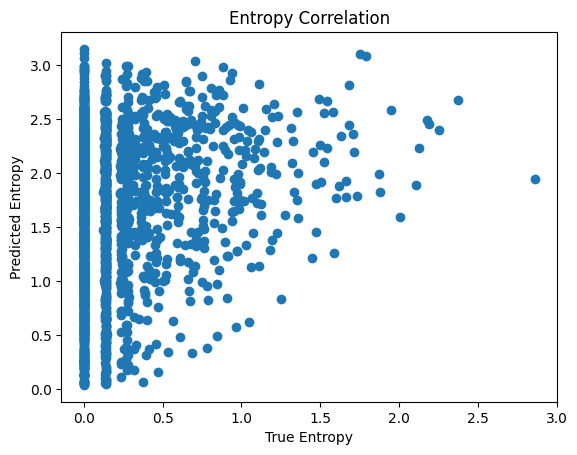

In [10]:
plt.scatter(true_entropies, pred_entropies)
plt.xlabel("True Entropy")
plt.ylabel("Predicted Entropy")
plt.title("Entropy Correlation")
plt.show()

Although the model achieves good KL divergence, it fails to capture
human uncertainty effectively, as shown by low entropy correlation.

The model is effective at predicting class probabilities but does not
accurately model human uncertainty, indicating a limitation of KL-based
training for uncertainty learning.

imporved version


In [11]:
model = SimpleCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses=[]
val_losses=[]

for epoch in range(10):
    model.train()
    train_loss=0
    
    for images, targets in train_loader:
        # logits = model(images)
        # outputs = torch.softmax(logits, dim=1)

        # loss = kl_divergence(targets, outputs)
        outputs = model(images)

        kl = kl_loss(targets, outputs)
        preds=torch.softmax(outputs, dim=1) 

        true_entropy = entropy(targets)
        pred_entropy = entropy(preds)

        entropy_loss = torch.mean((true_entropy - pred_entropy) ** 2)

        loss = kl + 0.1 * entropy_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)
    
    print(f"Epoch {epoch}, Loss: {loss.item()}")



Epoch 0, Loss: 2.1166000366210938
Epoch 1, Loss: 1.8239986896514893
Epoch 2, Loss: 1.7154998779296875
Epoch 3, Loss: 1.4827839136123657
Epoch 4, Loss: 1.3917399644851685
Epoch 5, Loss: 1.342956781387329
Epoch 6, Loss: 1.2982289791107178
Epoch 7, Loss: 1.132635474205017
Epoch 8, Loss: 1.1886837482452393
Epoch 9, Loss: 1.045149564743042


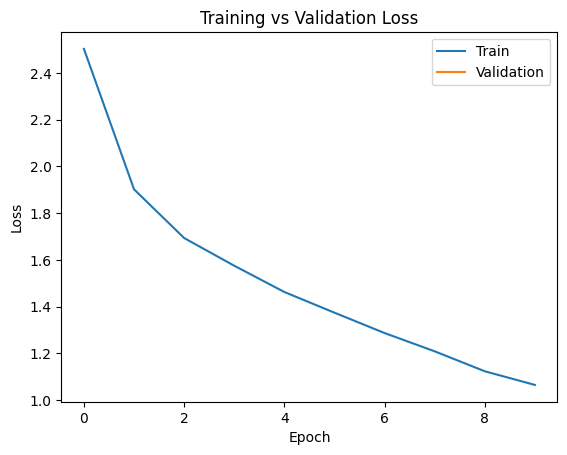

In [12]:
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [13]:
true_entropies = []
pred_entropies = []

model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        logits = model(images)
        preds = torch.softmax(logits, dim=1)

        true_entropies.extend(entropy(targets).cpu().numpy())
        pred_entropies.extend(entropy(preds).cpu().numpy())

corr = np.corrcoef(true_entropies, pred_entropies)[0,1]
print("Entropy Correlation:", corr)

Entropy Correlation: 0.18671713087912317


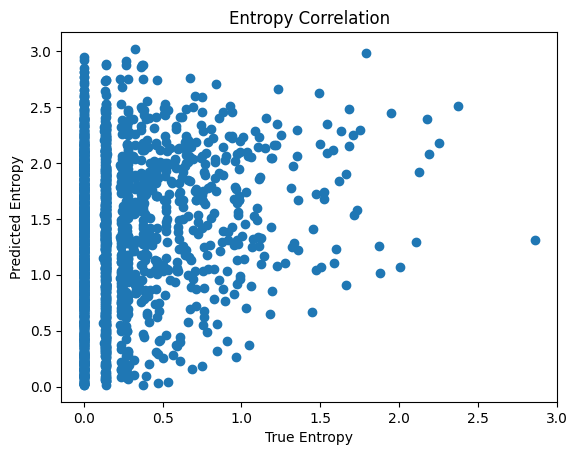

In [14]:
plt.scatter(true_entropies, pred_entropies)
plt.xlabel("True Entropy")
plt.ylabel("Predicted Entropy")
plt.title("Entropy Correlation")
plt.show()